# Tensor Puzzles (张量谜题)
- 作者： [Sasha Rush](http://rush-nlp.com) - [srush_nlp](https://twitter.com/srush_nlp) (以及 Marcos Treviso)

在学习 PyTorch 或 NumPy 等张量编程语言时，人们很容易依赖标准库（或者更坦白地说是 StackOverflow）去寻找解决一切问题的魔法函数。但在实际操作中，张量语言本身就具有极其强大的表达能力，仅通过最基本的原理和巧妙地利用**广播机制（broadcasting）**，你就可以完成绝大多数操作。

这里收集了 21 个张量谜题。就像国际象棋残局一样，这些谜题并不是为了模拟真实程序的复杂性，而是在一个简化的环境中锻炼你的基本功。每个谜题都要求你在不使用特殊API的情况下，重新实现 NumPy 标准库中的一个函数。

推荐在 Colab 中运行。点击下方链接并复制一份到你自己的云端硬盘即可开始：

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/srush/Tensor-Puzzles/blob/main/Tensor%20Puzzlers.ipynb)

In [3]:
!pip install -qqq "typeguard>=4.0.1" torchtyping hypothesis pytest git+https://github.com/chalk-diagrams/chalk
!wget -q https://github.com/srush/Tensor-Puzzles/raw/main/lib.py

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
from lib import draw_examples, make_test, run_test
import torch
import numpy as np
from torchtyping import TensorType as TT
tensor = torch.tensor

## 规则

1. 这些谜题的核心是**广播机制（broadcasting）**。请务必掌握好这一规则。

![](https://pbs.twimg.com/media/FQywor0WYAssn7Y?format=png&name=large)

2. 每个谜题都必须用 1 行代码（少于 80 个字符）来解决。
3. 你允许使用：`@` 矩阵乘法、算术运算、比较运算、`.shape`、任意索引切片方式（例如 `a[:j]`、`a[:, None]`、`a[arange(10)]`）以及你在前面谜题中已经实现的函数。
4. **禁止**使用其他任何方法。例如：禁止使用 `view`、`sum`、`take`、`squeeze`、`tensor`。

5. 你可以从以下两个基础函数开始使用：

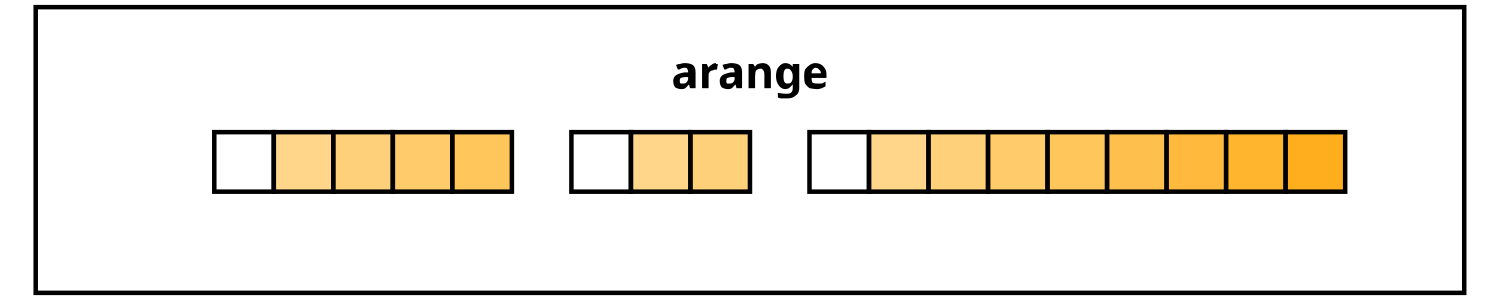

In [5]:
def arange(i: int):
    "Use this function to replace a for-loop."
    return torch.tensor(range(i))

draw_examples("arange", [{"" : arange(i)} for i in [5, 3, 9]])

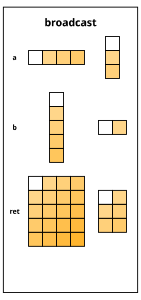

In [6]:
# Example of broadcasting.
examples = [(arange(4), arange(5)[:, None]) ,
            (arange(3)[:, None], arange(2))]
draw_examples("broadcast", [{"a": a, "b":b, "ret": a + b} for a, b in examples])

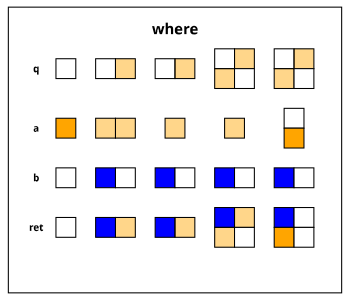

In [7]:
def where(q, a, b):
    "Use this function to replace an if-statement."
    return (q * a) + (~q) * b

# In diagrams, orange is positive/True, white is zero/False, and blue is negative.

examples = [(tensor([False]), tensor([10]), tensor([0])),
            (tensor([False, True]), tensor([1, 1]), tensor([-10, 0])),
            (tensor([False, True]), tensor([1]), tensor([-10, 0])),
            (tensor([[False, True], [True, False]]), tensor([1]), tensor([-10, 0])),
            (tensor([[False, True], [True, False]]), tensor([[0], [10]]), tensor([-10, 0])),
           ]
draw_examples("where", [{"q": q, "a":a, "b":b, "ret": where(q, a, b)} for q, a, b in examples])

## 谜题 1 - ones (全1向量)

计算 [ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html) —— 返回一个全为 1 的向量。

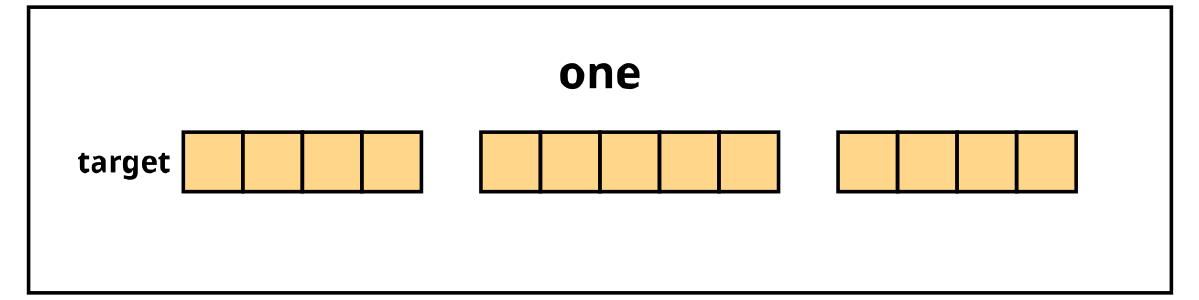

In [8]:
def ones_spec(out):
    for i in range(len(out)):
        out[i] = 1

def ones(i: int) -> TT["i"]:
    raise NotImplementedError

test_ones = make_test("one", ones, ones_spec, add_sizes=["i"])

In [10]:
#run_test(test_ones)

## 谜题 2 - sum (求和)

计算 [sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) —— 计算一个向量的元素总和。

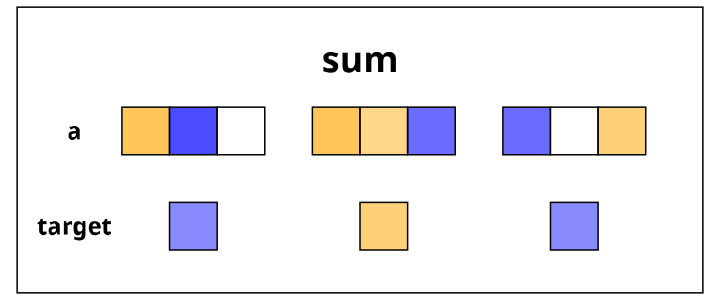

In [ ]:
def sum_spec(a, out):
    out[0] = 0
    for i in range(len(a)):
        out[0] += a[i]

def sum(a: TT["i"]) -> TT[1]:
    raise NotImplementedError


test_sum = make_test("sum", sum, sum_spec)

In [ ]:
# run_test(test_sum)

## 谜题 3 - outer (外积)

计算 [outer](https://numpy.org/doc/stable/reference/generated/numpy.outer.html) —— 计算两个向量的外积。

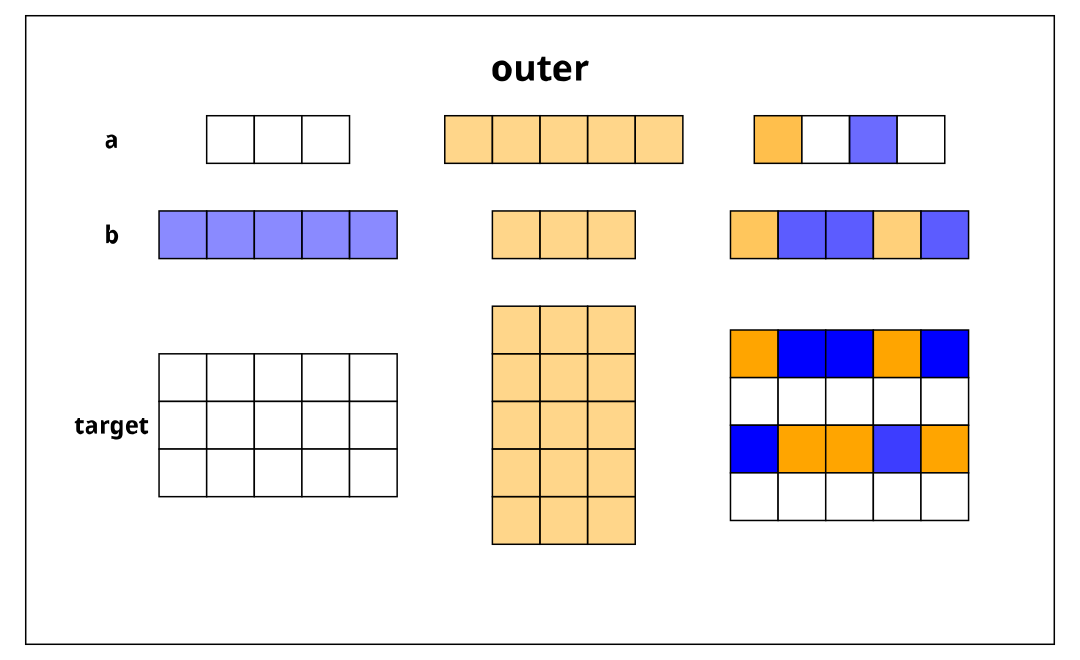

In [ ]:
def outer_spec(a, b, out):
    for i in range(len(out)):
        for j in range(len(out[0])):
            out[i][j] = a[i] * b[j]

def outer(a: TT["i"], b: TT["j"]) -> TT["i", "j"]:
    raise NotImplementedError

test_outer = make_test("outer", outer, outer_spec)

In [ ]:
# run_test(test_outer)

## 谜题 4 - diag (对角线)

计算 [diag](https://numpy.org/doc/stable/reference/generated/numpy.diag.html) —— 提取方阵的对角线向量。

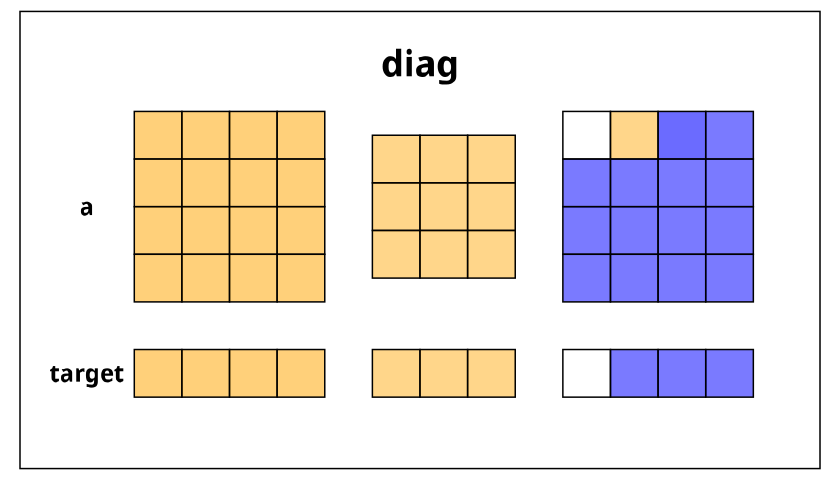

In [ ]:
def diag_spec(a, out):
    for i in range(len(a)):
        out[i] = a[i][i]

def diag(a: TT["i", "i"]) -> TT["i"]:
    raise NotImplementedError


test_diag = make_test("diag", diag, diag_spec)

In [ ]:
# run_test(test_diag)

## 谜题 5 - eye (单位矩阵)

计算 [eye](https://numpy.org/doc/stable/reference/generated/numpy.eye.html) —— 生成一个单位矩阵。

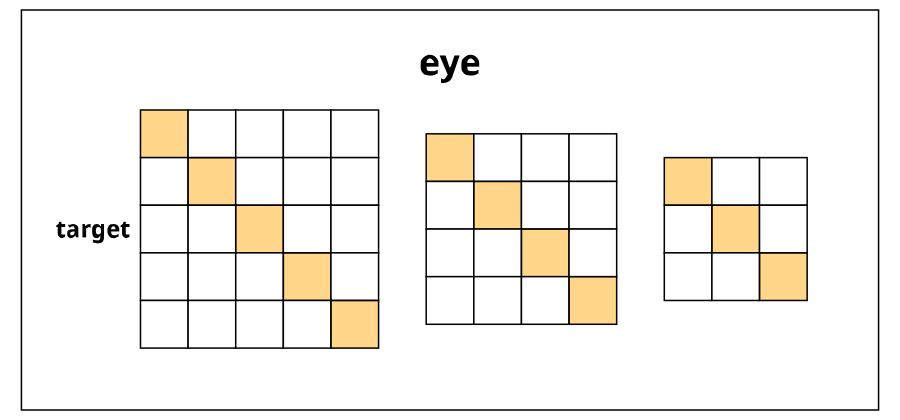

In [ ]:
def eye_spec(out):
    for i in range(len(out)):
        out[i][i] = 1

def eye(j: int) -> TT["j", "j"]:
    raise NotImplementedError

test_eye = make_test("eye", eye, eye_spec, add_sizes=["j"])

In [ ]:
# run_test(test_eye)

## 谜题 6 - triu (上三角矩阵)

计算 [triu](https://numpy.org/doc/stable/reference/generated/numpy.triu.html) —— 生成一个上三角矩阵。

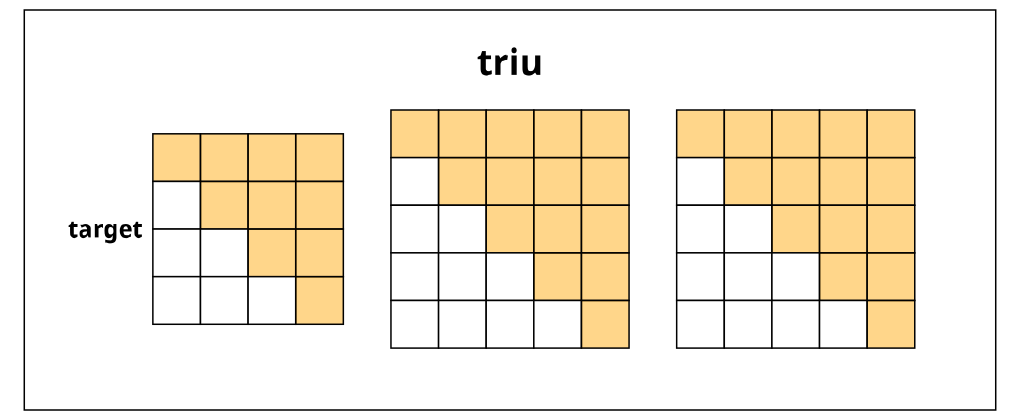

In [ ]:
def triu_spec(out):
    for i in range(len(out)):
        for j in range(len(out)):
            if i <= j:
                out[i][j] = 1
            else:
                out[i][j] = 0

def triu(j: int) -> TT["j", "j"]:
    raise NotImplementedError


test_triu = make_test("triu", triu, triu_spec, add_sizes=["j"])

In [ ]:
# run_test(test_triu)

## 谜题 7 - cumsum (累加和)

计算 [cumsum](https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html) —— 计算向量的累加和。

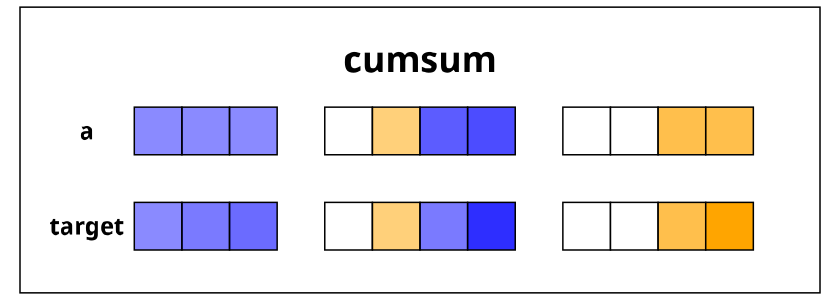

In [ ]:
def cumsum_spec(a, out):
    total = 0
    for i in range(len(out)):
        out[i] = total + a[i]
        total += a[i]

def cumsum(a: TT["i"]) -> TT["i"]:
    raise NotImplementedError

test_cumsum = make_test("cumsum", cumsum, cumsum_spec)

In [ ]:
# run_test(test_cumsum)

## 谜题 8 - diff (差分)

计算 [diff](https://numpy.org/doc/stable/reference/generated/numpy.diff.html) —— 计算向量相邻元素的差值。

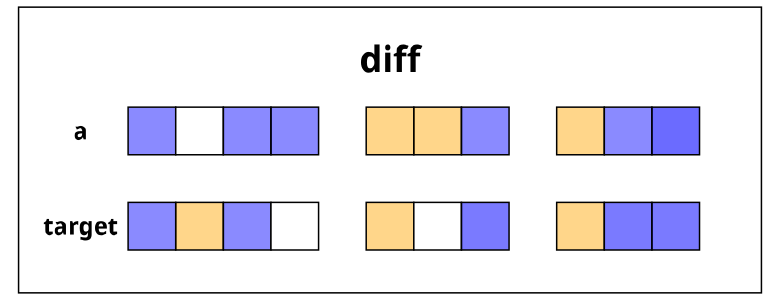

In [ ]:
def diff_spec(a, out):
    out[0] = a[0]
    for i in range(1, len(out)):
        out[i] = a[i] - a[i - 1]

def diff(a: TT["i"], i: int) -> TT["i"]:
    raise NotImplementedError

test_diff = make_test("diff", diff, diff_spec, add_sizes=["i"])

In [ ]:
# run_test(test_diff)

## 谜题 9 - vstack (垂直堆叠)

计算 [vstack](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html) —— 将两个向量垂直堆叠成一个矩阵。

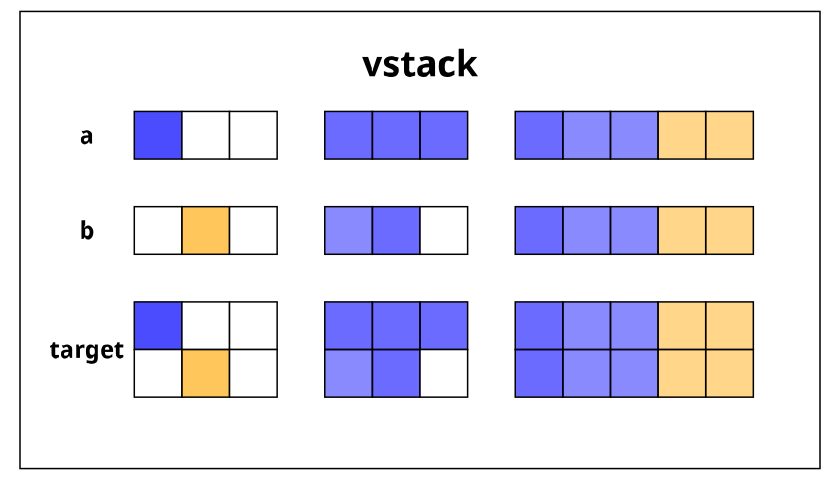

In [ ]:
def vstack_spec(a, b, out):
    for i in range(len(out[0])):
        out[0][i] = a[i]
        out[1][i] = b[i]

def vstack(a: TT["i"], b: TT["i"]) -> TT[2, "i"]:
    raise NotImplementedError


test_vstack = make_test("vstack", vstack, vstack_spec)

In [ ]:
# run_test(test_vstack)

## 谜题 10 - roll (循环滚动)

计算 [roll](https://numpy.org/doc/stable/reference/generated/numpy.roll.html) —— 将向量循环向左或向右平移 1 个位置。

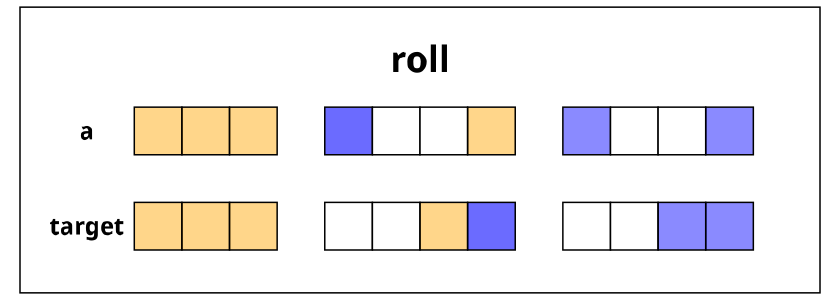

In [ ]:
def roll_spec(a, out):
    for i in range(len(out)):
        if i + 1 < len(out):
            out[i] = a[i + 1]
        else:
            out[i] = a[i + 1 - len(out)]

def roll(a: TT["i"], i: int) -> TT["i"]:
    raise NotImplementedError


test_roll = make_test("roll", roll, roll_spec, add_sizes=["i"])

In [ ]:
# run_test(test_roll)

## 谜题 11 - flip (翻转)

计算 [flip](https://numpy.org/doc/stable/reference/generated/numpy.flip.html) —— 逆序翻转一个向量。

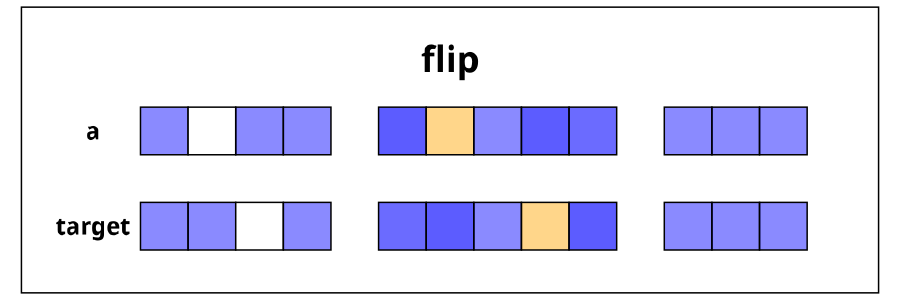

In [ ]:
def flip_spec(a, out):
    for i in range(len(out)):
        out[i] = a[len(out) - i - 1]

def flip(a: TT["i"], i: int) -> TT["i"]:
    raise NotImplementedError


test_flip = make_test("flip", flip, flip_spec, add_sizes=["i"])

In [ ]:
# run_test(test_flip)

## 谜题 12 - compress (压缩)

计算 [compress](https://numpy.org/doc/stable/reference/generated/numpy.compress.html) —— 只保留掩码（Mask）为 True 的元素（靠左对齐）。

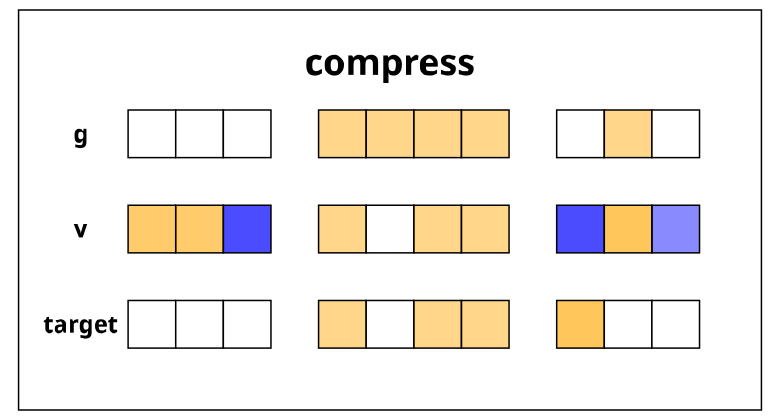

In [ ]:
def compress_spec(g, v, out):
    j = 0
    for i in range(len(g)):
        if g[i]:
            out[j] = v[i]
            j += 1

def compress(g: TT["i", bool], v: TT["i"], i:int) -> TT["i"]:
    raise NotImplementedError


test_compress = make_test("compress", compress, compress_spec, add_sizes=["i"])

In [ ]:
# run_test(test_compress)

## 谜题 13 - pad_to (填充/截断)

计算 pad_to —— 通过截断或补零来改变向量的大小。

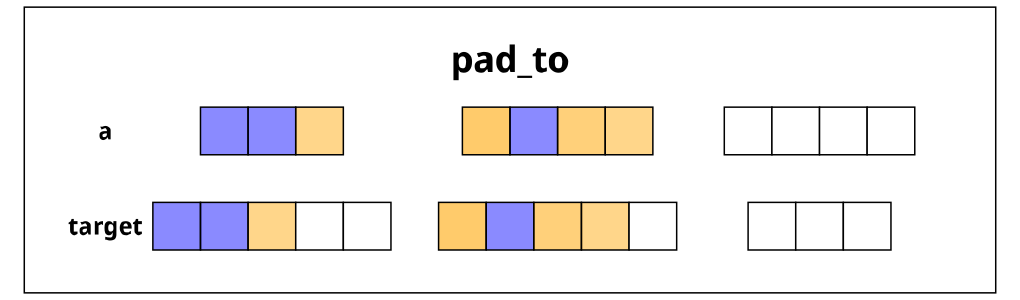

In [ ]:
def pad_to_spec(a, out):
    for i in range(min(len(out), len(a))):
        out[i] = a[i]


def pad_to(a: TT["i"], i: int, j: int) -> TT["j"]:
    raise NotImplementedError


test_pad_to = make_test("pad_to", pad_to, pad_to_spec, add_sizes=["i", "j"])

In [ ]:
# run_test(test_pad_to)

## 谜题 14 - sequence_mask (序列掩码)

计算 [sequence_mask](https://www.tensorflow.org/api_docs/python/tf/sequence_mask) —— 根据每个 batch 的指定长度进行截断和填充。

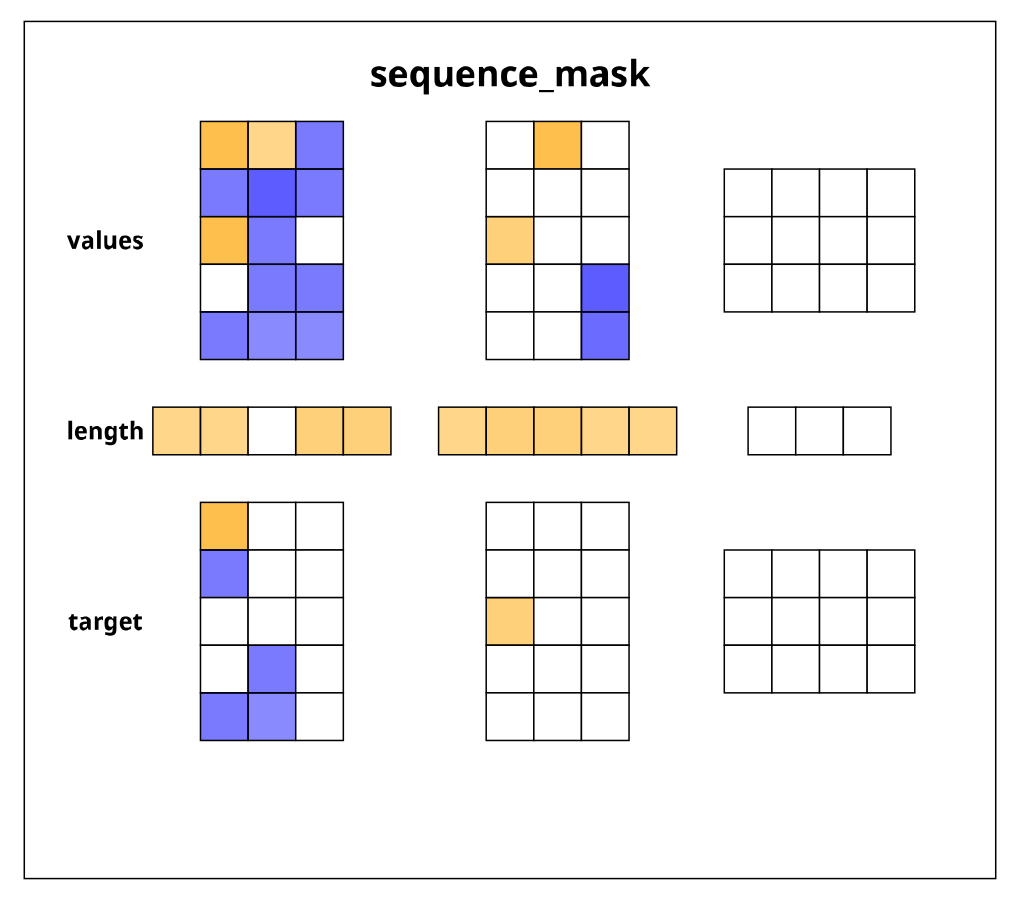

In [ ]:
def sequence_mask_spec(values, length, out):
    for i in range(len(out)):
        for j in range(len(out[0])):
            if j < length[i]:
                out[i][j] = values[i][j]
            else:
                out[i][j] = 0

def sequence_mask(values: TT["i", "j"], length: TT["i", int]) -> TT["i", "j"]:
    raise NotImplementedError


def constraint_set_length(d):
    d["length"] = d["length"] % d["values"].shape[1]
    return d


test_sequence = make_test("sequence_mask",
    sequence_mask, sequence_mask_spec, constraint=constraint_set_length
)

In [ ]:
# run_test(test_sequence)

## 谜题 15 - bincount (双重计数)

计算 [bincount](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html) —— 统计非负整数数组中每个值出现的次数。

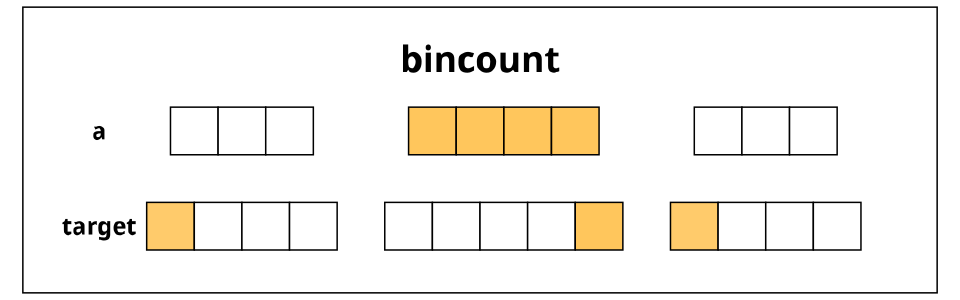

In [ ]:
def bincount_spec(a, out):
    for i in range(len(a)):
        out[a[i]] += 1

def bincount(a: TT["i"], j: int) -> TT["j"]:
    raise NotImplementedError


def constraint_set_max(d):
    d["a"] = d["a"] % d["return"].shape[0]
    return d


test_bincount = make_test("bincount",
    bincount, bincount_spec, add_sizes=["j"], constraint=constraint_set_max
)

In [ ]:
# run_test(test_bincount)

## 谜题 16 - scatter_add (散列加)

计算 [scatter_add](https://pytorch-scatter.readthedocs.io/en/1.3.0/functions/add.html) —— 将关联到相同位置的值累加到一起。

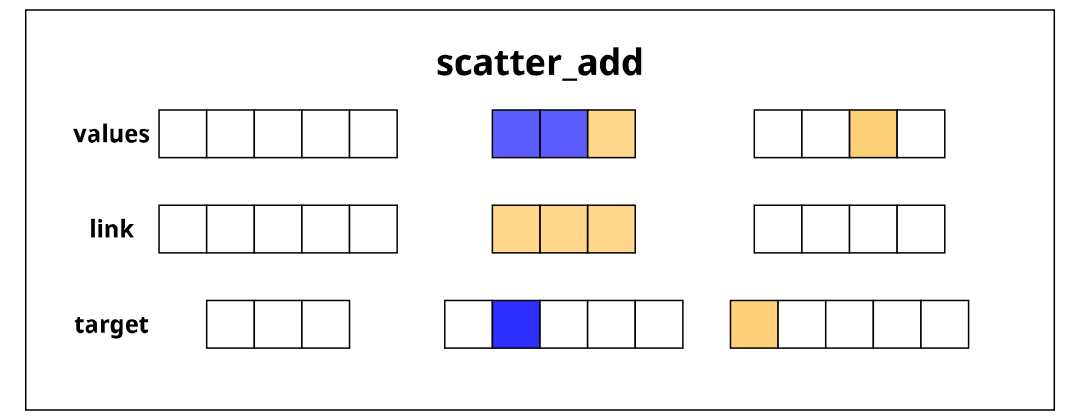

In [ ]:
def scatter_add_spec(values, link, out):
    for j in range(len(values)):
        out[link[j]] += values[j]

def scatter_add(values: TT["i"], link: TT["i"], j: int) -> TT["j"]:
    raise NotImplementedError


def constraint_set_max(d):
    d["link"] = d["link"] % d["return"].shape[0]
    return d


test_scatter_add = make_test("scatter_add",
    scatter_add, scatter_add_spec, add_sizes=["j"], constraint=constraint_set_max
)

In [ ]:
# run_test(test_scatter_add)

## 谜题 17 - flatten (展平)

计算 [flatten](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html) —— 将一个矩阵展开成一维向量。

In [ ]:
def flatten_spec(a, out):
    k = 0
    for i in range(len(a)):
        for j in range(len(a[0])):
            out[k] = a[i][j]
            k += 1

def flatten(a: TT["i", "j"], i:int, j:int) -> TT["i * j"]:
    raise NotImplementedError

test_flatten = make_test("flatten", flatten, flatten_spec, add_sizes=["i", "j"])

In [ ]:
# run_test(test_flatten)

## 谜题 18 - linspace (等差数列)

计算 [linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) —— 在指定的区间内返回均匀分布的数值。

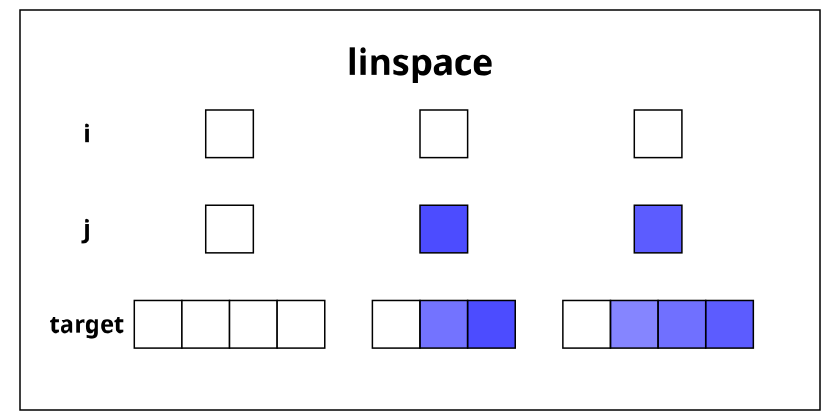

In [ ]:
def linspace_spec(i, j, out):
    for k in range(len(out)):
        out[k] = float(i + (j - i) * k / max(1, len(out) - 1))

def linspace(i: TT[1], j: TT[1], n: int) -> TT["n", float]:
    raise NotImplementedError

test_linspace = make_test("linspace", linspace, linspace_spec, add_sizes=["n"])

In [ ]:
# run_test(test_linspace)

## 谜题 19 - heaviside (赫维赛德阶跃函数)

计算 [heaviside](https://numpy.org/doc/stable/reference/generated/numpy.heaviside.html) —— 计算阶跃函数的值。

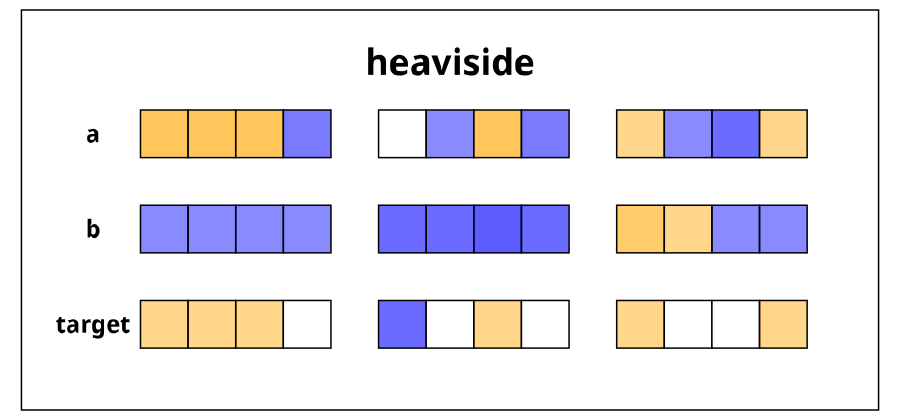

In [ ]:
def heaviside_spec(a, b, out):
    for k in range(len(out)):
        if a[k] == 0:
            out[k] = b[k]
        else:
            out[k] = int(a[k] > 0)

def heaviside(a: TT["i"], b: TT["i"]) -> TT["i"]:
    raise NotImplementedError

test_heaviside = make_test("heaviside", heaviside, heaviside_spec)

In [ ]:
# run_test(test_heaviside)

## 谜题 20 - repeat (1维重复)

计算 [repeat](https://pytorch.org/docs/stable/generated/torch.Tensor.repeat.html) —— 沿指定维度复制向量。

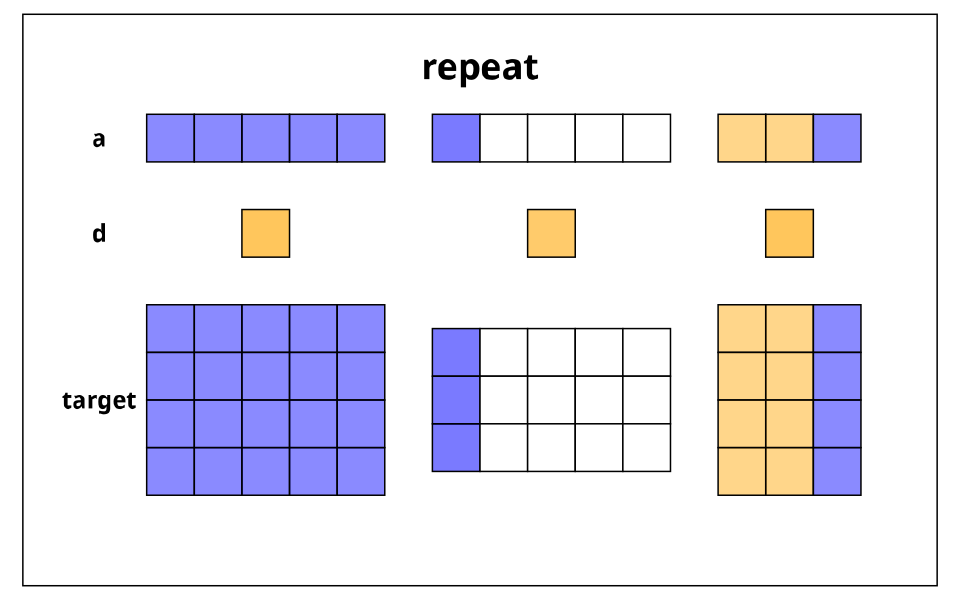

In [ ]:
def repeat_spec(a, d, out):
    for i in range(d[0]):
        for k in range(len(a)):
            out[i][k] = a[k]

def constraint_set(d):
    d["d"][0] = d["return"].shape[0]
    return d


def repeat(a: TT["i"], d: TT[1]) -> TT["d", "i"]:
    raise NotImplementedError

test_repeat = make_test("repeat", repeat, repeat_spec, constraint=constraint_set)


# ## Puzzle 21 - bucketize
#
# Compute [bucketize](https://pytorch.org/docs/stable/generated/torch.bucketize.html)

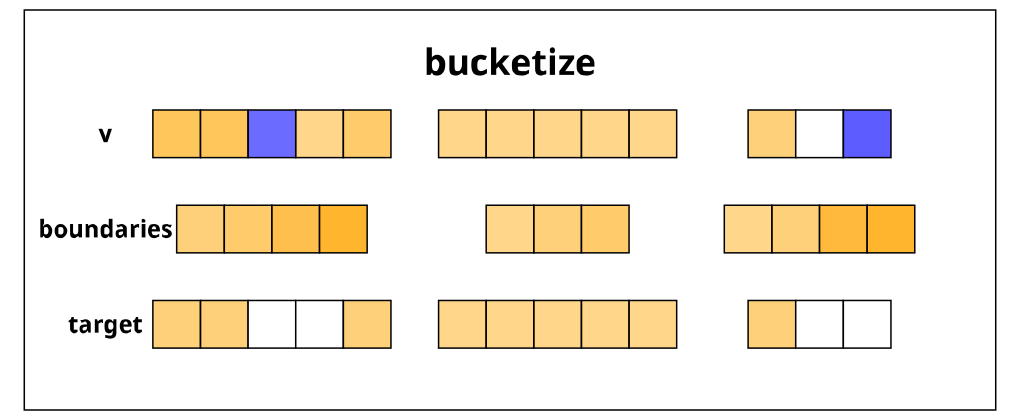

In [ ]:
def bucketize_spec(v, boundaries, out):
    for i, val in enumerate(v):
        out[i] = 0
        for j in range(len(boundaries)-1):
            if val >= boundaries[j]:
                out[i] = j + 1
        if val >= boundaries[-1]:
            out[i] = len(boundaries)


def constraint_set(d):
    d["boundaries"] = np.abs(d["boundaries"]).cumsum()
    return d


def bucketize(v: TT["i"], boundaries: TT["j"]) -> TT["i"]:
    raise NotImplementedError

test_bucketize = make_test("bucketize", bucketize, bucketize_spec,
                           constraint=constraint_set)


#
# # Speed Run Mode!
#
# What is the smallest you can make each of these?

In [ ]:
import inspect
fns = (ones, sum, outer, diag, eye, triu, cumsum, diff, vstack, roll, flip,
       compress, pad_to, sequence_mask, bincount, scatter_add)

for fn in fns:
    lines = [l for l in inspect.getsource(fn).split("\n") if not l.strip().startswith("#")]

    if len(lines) > 3:
        print(fn.__name__, len(lines[2]), "(more than 1 line)")
    else:
        print(fn.__name__, len(lines[1]))

ones 29
sum 29
outer 29
diag 29
eye 29
triu 29
cumsum 29
diff 29
vstack 29
roll 29
flip 29
compress 29
pad_to 29
sequence_mask 29
bincount 29
scatter_add 29
